In [2]:
import torch 
import pandas as pd
import umap 

from matplotlib import pyplot as plt 
import seaborn as sbn
from sklearn.decomposition import PCA

import numpy as np 

/home/teddy/miniconda3/envs/lincs-gsnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# dxdt ~ f(x) 
model = torch.load('/home/teddy/local/lincs-gsnn/workflow/runs/default/pretrain/pretrained_model.pt', map_location=torch.device('cpu'), weights_only=False).eval()

# viab ~ f(x) 
model_viab = torch.load('/home/teddy/local/lincs-traj/workflow/runs/exp/default_v02/output/viab/final_model.pt', map_location=torch.device('cpu'), weights_only=False).eval()

AttributeError: 'collections.OrderedDict' object has no attribute 'eval'

In [4]:
root = '/home/teddy/local/lincs-traj/workflow/runs/exp/default_v02/output/predict_grid/'

pred_meta = pd.read_csv(f'{root}/pred_meta.csv')
pred_meta.head()

x = [] 
for i,row in pred_meta.iterrows():
    x.append(torch.load(f'{root}/obs/{row['file_name']}', weights_only=False)['mean']) 

x = torch.stack(x, 0)
x.shape

torch.Size([528, 100, 978])

In [5]:
pred_meta.head() 

,pert_id,cell_iname,dose,time_min,time_max,n_time_pts,file_name
0,BRD-K49328571,HME1,0.000,0,24.0,100,pred__BRD-K49328571_HME1_0.0.pt
1,BRD-K49328571,HME1,0.001,0,24.0,100,pred__BRD-K49328571_HME1_0.001.pt
2,BRD-K49328571,HME1,0.010,0,24.0,100,pred__BRD-K49328571_HME1_0.01.pt
3,BRD-K49328571,HME1,0.100,0,24.0,100,pred__BRD-K49328571_HME1_0.1.pt
4,BRD-K49328571,HME1,1.000,0,24.0,100,pred__BRD-K49328571_HME1_1.0.pt


In [25]:
cell_x = x[pred_meta[lambda x: x.cell_iname == 'HME1'].index].view(-1, 978).detach().cpu().numpy()

#reducer = umap.UMAP(n_components=2, min_dist=0.1, n_neighbors=25, metric='cosine') 
#reducer.fit(cell_x + np.random.normal(0, 0.1, cell_x.shape))
#u = reducer.transform(cell_x)

reducer = PCA(n_components=2)
u = reducer.fit_transform(cell_x)


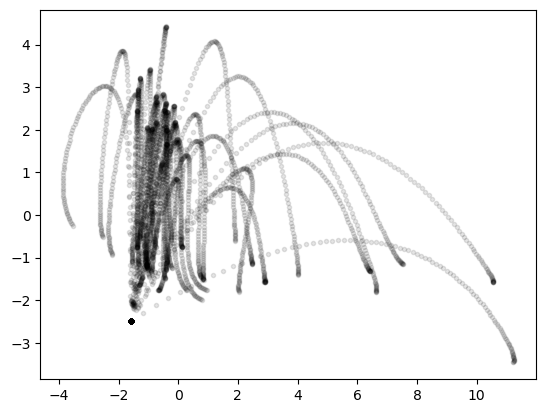

In [26]:
plt.figure() 
plt.plot(u[:,0], u[:,1], 'k.', alpha=0.1)
plt.show() 